<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nombre:** Laila Montserrat Bulhosen Ramos Matricula: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje

**Objetivo:** Explorar la representación semántica de palabras e identifica los diferentes dominios temáticos contenidos en el conjunto de datos proporcionado mediante la visualización 2D de embeddings de palabras.

**Link Github:** [Representacion de texto - Embeddings](https://github.com/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Embeddings.ipynb)

**Fecha:** 14 marzo 2026

In [1]:
### Conexión Google driver
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Preprocesamiento de texto**

In [2]:
### Librerias necesasrias
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

In [3]:
!pip install unidecode

In [4]:
from unidecode import unidecode

In [5]:
pd.set_option('display.max_colwidth', None)

In [6]:
### Import CSV
text = pd.read_csv('/content/drive/MyDrive/Procesamiento Lenguaje Natural/Ejercicios de Representación de textos - Embeddings.csv')

display(text)

,frase
0,La ciberseguridad protege la información digital.
1,La inteligencia artificial transforma múltiples industrias.
2,"El baloncesto combina velocidad, técnica y trabajo en equipo."
3,El hardware y el software son complementarios en la computación.
4,La democracia permite la participación ciudadana en decisiones.
...,...
143,La natación es una disciplina que fortalece todo el cuerpo.
144,Los atletas requieren entrenamiento constante para mejorar.
145,Las políticas públicas buscan atender necesidades sociales.
146,Los partidos políticos representan diferentes ideologías.


In [7]:
### Convertir a minúsculas
text = text['frase'].str.lower()
#display(text)

In [8]:
### Eliminar puntuaciones
text = text.apply(lambda x: re.sub(r'[^\w\s]', '', x))

display(text)

,frase
0,la ciberseguridad protege la información digital
1,la inteligencia artificial transforma múltiples industrias
2,el baloncesto combina velocidad técnica y trabajo en equipo
3,el hardware y el software son complementarios en la computación
4,la democracia permite la participación ciudadana en decisiones
...,...
143,la natación es una disciplina que fortalece todo el cuerpo
144,los atletas requieren entrenamiento constante para mejorar
145,las políticas públicas buscan atender necesidades sociales
146,los partidos políticos representan diferentes ideologías


In [9]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [10]:
### Unir frases en un texto
text_all = ''.join(text.tolist())
#print(text_all)


In [11]:
### Tokenizacion

tokens = word_tokenize(text_all, language = 'spanish')

stop_words = set(stopwords.words('spanish'))

tokens_filtrados = [word for word in tokens if word not in stop_words and word.isalpha()]
print(tokens_filtrados)

['ciberseguridad', 'protege', 'información', 'digital', 'inteligencia', 'artificial', 'transforma', 'múltiples', 'industrias', 'baloncesto', 'combina', 'velocidad', 'técnica', 'trabajo', 'equipo', 'hardware', 'software', 'complementarios', 'computación', 'democracia', 'permite', 'participación', 'ciudadana', 'decisiones', 'natación', 'disciplina', 'fortalece', 'cuerpo', 'algoritmos', 'base', 'programación', 'informática', 'hardware', 'software', 'complementarios', 'computación', 'hardware', 'software', 'complementarios', 'computación', 'algoritmos', 'base', 'programación', 'informática', 'inteligencia', 'artificial', 'transforma', 'múltiples', 'industrias', 'partidos', 'políticos', 'representan', 'diferentes', 'ideologías', 'natación', 'disciplina', 'fortalece', 'cuerpo', 'debate', 'público', 'fortalece', 'vida', 'democrática', 'baloncesto', 'combina', 'velocidad', 'técnica', 'trabajo', 'equipo', 'atletas', 'requieren', 'entrenamiento', 'constante', 'mejorar', 'debate', 'público', 'for

## **Embeddings**

In [13]:
# Librerías necesarias
!pip install gensim matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.9 MB/s eta 0:00:00


In [14]:
from gensim.models import KeyedVectors
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import gensim.downloader as api
import numpy as np

In [15]:
### Cargar modelo de embeddings en español

model = api.load('fasttext-wiki-news-subwords-300')

print('Modelo cargado con éxito! :)')

[==================================================] 100.0% 958.5/958.4MB downloaded
Modelo cargado con éxito! :)


In [16]:
### Eliminar palabras duplicadas
from collections import Counter

In [18]:
frecuencia = Counter(tokens_filtrados)
print(frecuencia)

Counter({'fortalece': 21, 'permite': 14, 'ciberseguridad': 13, 'protege': 13, 'información': 13, 'digital': 13, 'natación': 13, 'disciplina': 13, 'cuerpo': 13, 'elecciones': 13, 'libres': 13, 'esenciales': 13, 'derecho': 13, 'inteligencia': 11, 'artificial': 11, 'transforma': 11, 'múltiples': 11, 'industrias': 11, 'baloncesto': 11, 'combina': 11, 'velocidad': 11, 'técnica': 11, 'trabajo': 11, 'equipo': 11, 'hardware': 10, 'software': 10, 'complementarios': 10, 'computación': 10, 'algoritmos': 10, 'base': 10, 'programación': 10, 'informática': 10, 'olimpismo': 10, 'busca': 10, 'unión': 10, 'pueblos': 10, 'través': 10, 'deporte': 10, 'políticas': 10, 'públicas': 10, 'buscan': 10, 'atender': 10, 'necesidades': 10, 'sociales': 10, 'partidos': 9, 'políticos': 9, 'representan': 9, 'diferentes': 9, 'ideologías': 9, 'fútbol': 9, 'deportes': 9, 'populares': 9, 'mundo': 9, 'democracia': 8, 'participación': 8, 'ciudadana': 8, 'decisiones': 8, 'debate': 8, 'público': 8, 'vida': 8, 'democrática': 8

In [21]:
tokens_unicos = list()

for palabra in frecuencia:
  if palabra not in tokens_unicos:
    tokens_unicos.append(palabra)

#print(f'Tokens únicos: {tokens_unicos}')

Tokens únicos: ['ciberseguridad', 'protege', 'información', 'digital', 'inteligencia', 'artificial', 'transforma', 'múltiples', 'industrias', 'baloncesto', 'combina', 'velocidad', 'técnica', 'trabajo', 'equipo', 'hardware', 'software', 'complementarios', 'computación', 'democracia', 'permite', 'participación', 'ciudadana', 'decisiones', 'natación', 'disciplina', 'fortalece', 'cuerpo', 'algoritmos', 'base', 'programación', 'informática', 'partidos', 'políticos', 'representan', 'diferentes', 'ideologías', 'debate', 'público', 'vida', 'democrática', 'atletas', 'requieren', 'entrenamiento', 'constante', 'mejorar', 'nube', 'almacenar', 'procesar', 'datos', 'gran', 'escala', 'elecciones', 'libres', 'esenciales', 'derecho', 'olimpismo', 'busca', 'unión', 'pueblos', 'través', 'deporte', 'políticas', 'públicas', 'buscan', 'atender', 'necesidades', 'sociales', 'fútbol', 'deportes', 'populares', 'mundo']


In [23]:
### Filtrar palabras que estén en el vocabulario del modelo

palabras_filtradas = [p for p in tokens_unicos if p in model.key_to_index]
print(f'Palabras dentro del modelo: {palabras_filtradas}')

Palabras dentro del modelo: ['protege', 'información', 'digital', 'inteligencia', 'artificial', 'transforma', 'múltiples', 'industrias', 'baloncesto', 'combina', 'velocidad', 'técnica', 'trabajo', 'equipo', 'hardware', 'software', 'democracia', 'permite', 'participación', 'ciudadana', 'decisiones', 'disciplina', 'cuerpo', 'base', 'programación', 'informática', 'partidos', 'políticos', 'representan', 'diferentes', 'debate', 'público', 'vida', 'democrática', 'atletas', 'entrenamiento', 'constante', 'mejorar', 'nube', 'datos', 'gran', 'escala', 'elecciones', 'libres', 'derecho', 'busca', 'unión', 'pueblos', 'través', 'deporte', 'políticas', 'públicas', 'buscan', 'atender', 'necesidades', 'sociales', 'fútbol', 'deportes', 'populares', 'mundo']


In [24]:
### Obtener embeddings
X = np.array([model[p] for p in palabras_filtradas])

print(X.shape)
print(X[0])

(60, 300)
[-0.0068156  -0.030262    0.0016074   0.029909   -0.084335   -0.087736
 -0.05777    -0.079991    0.011931    0.027433    0.073649   -0.012916
  0.0054739   0.14466    -0.037014   -0.0039771   0.085585    0.045087
  0.046854    0.012374   -0.019366    0.049203   -0.050745    0.063415
  0.0045093  -0.0094252  -0.022277   -0.030695   -0.059326    0.0056623
  0.025892   -0.00044789 -0.056586    0.0014836  -0.039314    0.10406
 -0.047969   -0.0041198  -0.0013186   0.060939   -0.03517    -0.10249
 -0.092469   -0.0060176   0.067486    0.12793     0.083213   -0.057962
  0.011847   -0.053237    0.0048847   0.026212    0.032151    0.081205
  0.014011   -0.043072   -0.065373   -0.012084   -0.0065605   0.085739
  0.01164     0.02175     0.066653   -0.0084064  -0.053736   -0.048242
 -0.0011358  -0.11471    -0.031492   -0.10123     0.057998    0.021816
  0.004925    0.043243    0.032898    0.0087524  -0.016604   -0.016592
  0.043827   -0.054537    0.033229    0.031892   -0.025527    0.0790

### **Visualización**

In [28]:
### Reducción de dimensionalidad con t-SNE

tsne = TSNE(n_components= 2, random_state= 42, perplexity= 5, init= 'pca')
X_2d = tsne.fit_transform(X)

print(X_2d.shape)
print(X_2d)

(60, 2)
[[ 49.634457     4.915724  ]
 [-35.55655      6.686062  ]
 [ 58.59898     42.94867   ]
 [ -1.0831535  -19.762613  ]
 [ 44.130577    26.856052  ]
 [ 24.011162    12.814782  ]
 [ -0.606203   -38.207863  ]
 [  1.5235107  -30.62989   ]
 [  8.588709   -26.690931  ]
 [ 22.11681      6.156626  ]
 [-55.13624    -14.61911   ]
 [-25.994421   -14.5968275 ]
 [-35.889133    -7.1702805 ]
 [ -7.5308776   55.883083  ]
 [ 58.449177    56.062977  ]
 [ 60.104084    51.387096  ]
 [-20.080883   -24.795736  ]
 [ 30.90798     22.017368  ]
 [-30.319735     3.966896  ]
 [-13.319097   -13.183796  ]
 [-20.238983   -50.852924  ]
 [  7.2356973   -7.8639073 ]
 [-41.986744   -11.864841  ]
 [ 38.900955    13.276701  ]
 [-31.390976    12.367738  ]
 [-24.943089    -6.4717846 ]
 [-12.345907   -34.510532  ]
 [-68.65555     26.160574  ]
 [ 30.688501    10.089032  ]
 [  1.7037895  -44.760815  ]
 [  5.362525    18.649166  ]
 [-75.04626      8.731435  ]
 [ 38.653366   -42.720684  ]
 [-17.212273   -20.433105  ]
 [ 13.

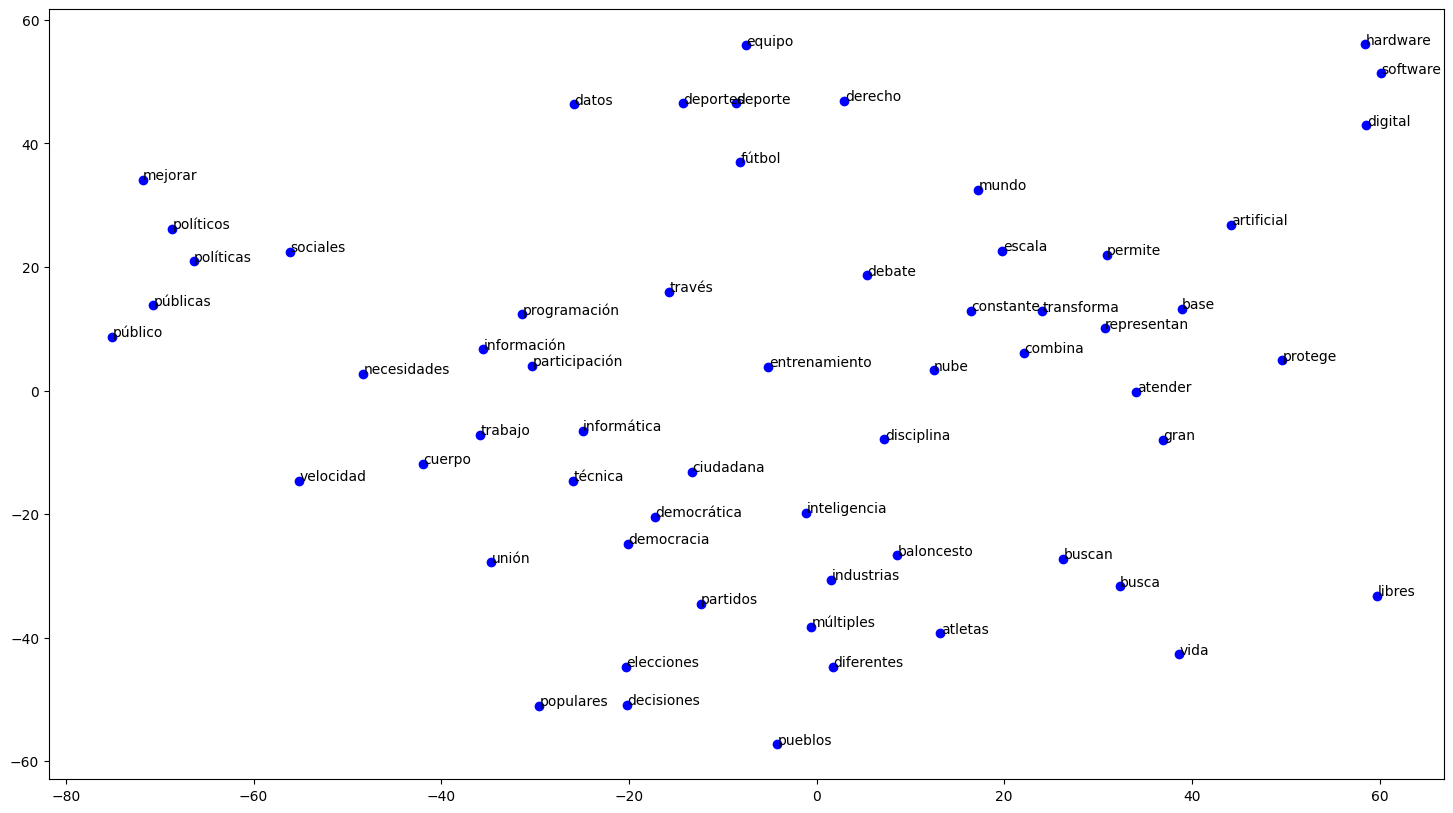

In [38]:
### Crear visualización

plt.figure(figsize= (18,10))
for i, palabra in enumerate(palabras_filtradas):
  x, y = X_2d[i, 0], X_2d[i, 1]
  plt.scatter(x, y, c= 'blue')
  plt.text(x+0.05, y+0.05, palabra, fontsize= 10)

plt.show()

Fue posible identificar cuatro grupos de palabras relacionadas, sin embargo, se encontraron algunas palabras que no fueron graficadas cerca de algún grupo existente como las palabras baloncesto o atletas que sus coordenadas fueron lejos del grupo donde se encontraron las palabras equipo, deporte, fútbol apesar de tener una similitud de contexto.

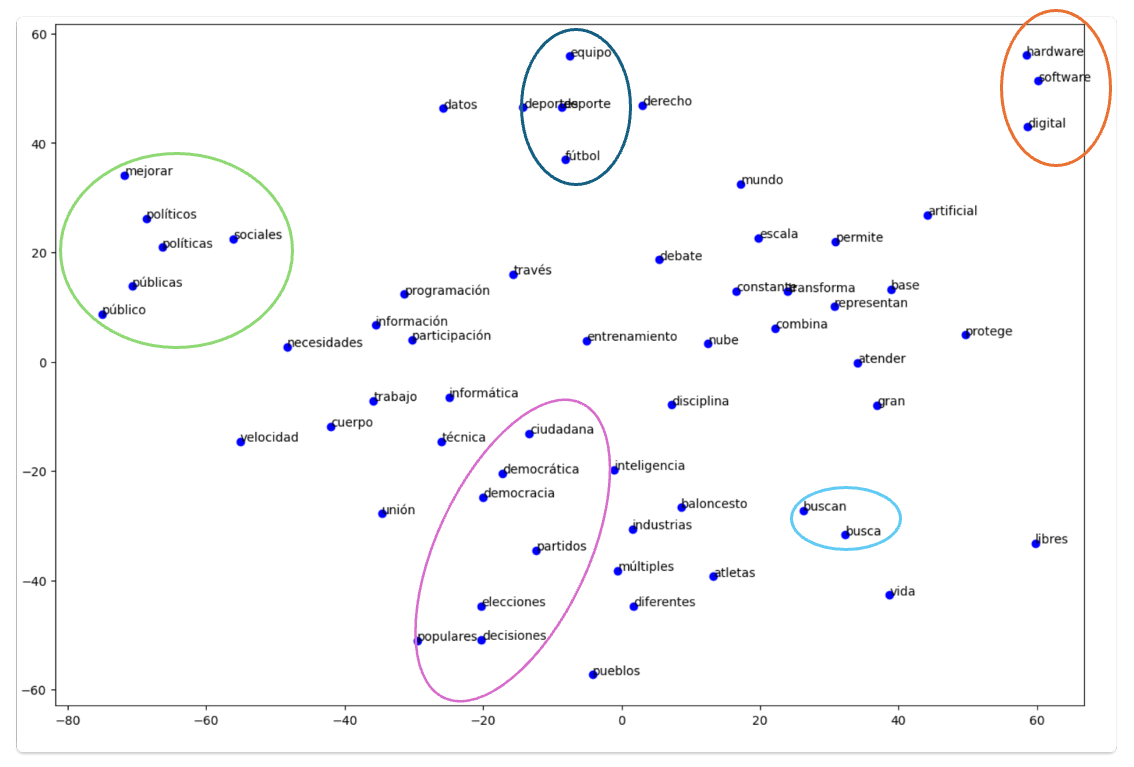

### **Lematización**

In [39]:
import spacy

In [40]:
!python -m spacy download es_core_news_sm
!python -m spacy link fr_core_news_sm fr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 26.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
⚠ As of spaCy v3.0, model symlinks are not supported anymore. You can
load trained pipeline packages using their full names or from a directory
path.


In [42]:
nlp = spacy.load('es_core_news_sm')

text_to_lemmatize = " ".join(palabras_filtradas)
palabras_lematizadas = nlp(text_to_lemmatize)

print('Spacy lematización:\n')
for token in palabras_lematizadas:
  print(token.text, '->', token.lemma_)

Spacy lematización:

protege -> proteger
información -> información
digital -> digital
inteligencia -> inteligencia
artificial -> artificial
transforma -> transformar
múltiples -> múltiple
industrias -> industria
baloncesto -> baloncesto
combina -> combinar
velocidad -> velocidad
técnica -> técnico
trabajo -> trabajo
equipo -> equipo
hardware -> hardware
software -> softwarar
democracia -> democracia
permite -> permitir
participación -> participación
ciudadana -> ciudadano
decisiones -> decisión
disciplina -> disciplina
cuerpo -> cuerpo
base -> base
programación -> programación
informática -> informático
partidos -> partido
políticos -> político
representan -> representar
diferentes -> diferente
debate -> debate
público -> público
vida -> vida
democrática -> democrático
atletas -> atletas
entrenamiento -> entrenamiento
constante -> constante
mejorar -> mejorar
nube -> nube
datos -> dato
gran -> gran
escala -> escala
elecciones -> elección
libres -> libre
derecho -> derecho
busca -> bus

In [49]:
tokens_unicos_lem = list()

for palabra in palabras_lematizadas:
  if palabra not in tokens_unicos_lem:
    tokens_unicos_lem.append(palabra)

print(tokens_unicos_lem)

[protege, información, digital, inteligencia, artificial, transforma, múltiples, industrias, baloncesto, combina, velocidad, técnica, trabajo, equipo, hardware, software, democracia, permite, participación, ciudadana, decisiones, disciplina, cuerpo, base, programación, informática, partidos, políticos, representan, diferentes, debate, público, vida, democrática, atletas, entrenamiento, constante, mejorar, nube, datos, gran, escala, elecciones, libres, derecho, busca, unión, pueblos, través, deporte, políticas, públicas, buscan, atender, necesidades, sociales, fútbol, deportes, populares, mundo]


In [51]:
### Obtener embeddings de palabras lematizadas

X = np.array([model[p.lemma_] for p in tokens_unicos_lem if p.lemma_ in model.key_to_index])

print(X.shape)
print(X[0])

(57, 300)
[ 0.0083946  -0.035542   -0.016731    0.033868   -0.01218     0.0052216
 -0.0066673  -0.087035    0.0069911  -0.038562    0.044547    0.013469
 -0.018188    0.032483   -0.0099897   0.0081006   0.07365     0.014721
  0.069298    0.010331   -0.030428   -0.010299   -0.020069    0.096541
  0.018084    0.0081377  -0.00024333 -0.0042063  -0.043213   -0.0049604
  0.031061   -0.0057818  -0.036919    0.066934   -0.023298    0.022456
  0.028225    0.013164   -0.0034075   0.00034265  0.030385   -0.04669
 -0.039452    0.0012699   0.042395    0.034311    0.020699    0.0063049
  0.019008   -0.05629    -0.025264   -0.00086274  0.028056    0.012169
  0.0052132  -0.018813   -0.022944   -0.0027526   0.012212    0.015978
 -0.049617    0.0096475   0.062979   -0.024163    0.013635    0.027049
  0.00078844 -0.049724    0.020615   -0.005958    0.031636   -0.0019444
  0.026386    0.012359   -0.0043038  -0.0055719   0.015683   -0.0014269
 -0.023551   -0.031373    0.0011142  -0.03022     0.0091805   0

In [52]:
### Reducción de dimensionalidad con t-SNE

tsne_2 = TSNE(n_components= 2, random_state= 42, perplexity= 5, init= 'pca')
X_2d_2 = tsne_2.fit_transform(X)

print(X_2d_2.shape)
print(X_2d_2)

(57, 2)
[[-7.39104939e+00  5.87632217e+01]
 [-8.07737045e+01 -5.28416557e+01]
 [ 9.01408768e+01 -2.81490631e+01]
 [ 4.87720413e+01 -4.57406654e+01]
 [ 9.70431137e+01  1.11094007e+01]
 [ 5.27284813e+01  7.27187271e+01]
 [ 1.02606369e+02  8.73438339e+01]
 [ 2.57727108e+01 -1.98593330e+01]
 [-5.44596815e+00 -8.44733775e-01]
 [-9.70282059e+01 -9.91003227e+00]
 [ 6.83927536e+01 -9.99866180e+01]
 [-6.41093140e+01 -2.36790218e+01]
 [-6.80342941e+01  7.20665894e+01]
 [ 7.04878387e+01 -3.74713020e+01]
 [ 1.86459713e+01 -6.58103256e+01]
 [ 4.40499001e+01  1.03263214e+02]
 [-8.10616531e+01 -3.87154274e+01]
 [ 2.39981098e+01 -9.38853760e+01]
 [-8.93393478e+01 -9.15077057e+01]
 [ 2.98022118e+01 -3.28729782e+01]
 [-5.97522163e+01 -5.22949600e+00]
 [ 6.85593948e+01  3.80093002e+01]
 [-9.82328186e+01 -5.00981598e+01]
 [-1.51729136e+01 -8.54621429e+01]
 [-1.48724457e+02 -3.90598679e+01]
 [ 6.04353752e+01  6.03864136e+01]
 [ 1.05625534e+02  1.03365250e+02]
 [ 8.07972107e+01  6.62741623e+01]
 [ 1.1064536

IndexError: index 57 is out of bounds for axis 0 with size 57

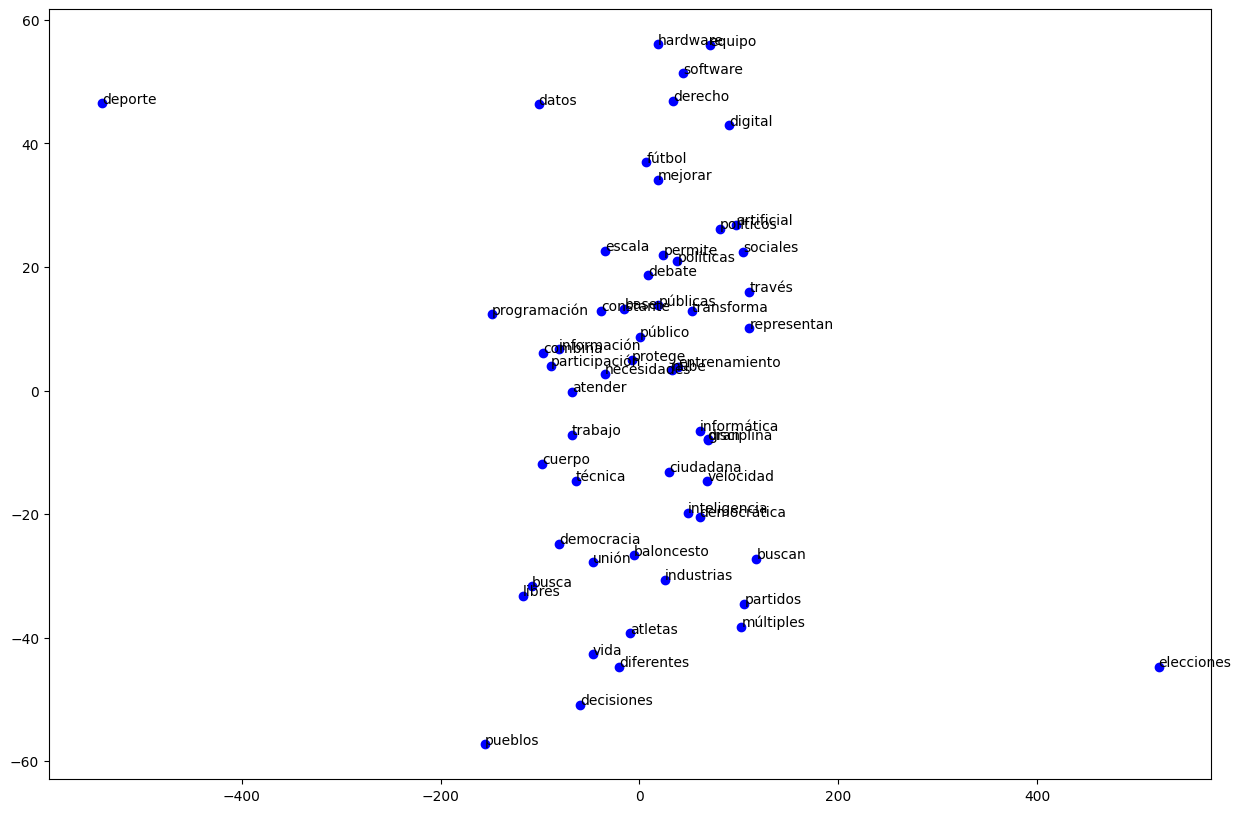

In [56]:
### Crear visualización

plt.figure(figsize= (15,10))
for i, palabra in enumerate(palabras_filtradas):
  x, y = X_2d_2[i, 0], X_2d[i, 1]
  plt.scatter(x, y, c= 'blue')
  plt.text(x+0.05, y+0.05, palabra, fontsize= 10)

plt.show()